In [434]:
import numpy as np
import random

In [435]:
# =====================================
# PARAMETERS
# =====================================

sample_rate = 1e9          # 1 Gs/s
event_window = 2e-6          # 2 us
samples_per_event = int(sample_rate * event_window)  # number of samples in the event window

num_events = 100
total_samples = num_events * samples_per_event

baseline = 2000
noise_sigma = 15

pulse_height = 900
pulse_width = 5

# probabilities of different events
single_peak_prob = 0.98
double_peak_prob = 0.20



In [436]:
# =====================================
# PULSE SHAPE
# =====================================

def gaussian_pulse(center, width, height, N):
    
    x = np.arange(N)
    
    pulse = height * np.exp(-((x-center)**2)/(2*width**2))
    
    return pulse



In [437]:

# ---------------------------------
# Generate waveform
# ---------------------------------

waveform = np.zeros(total_samples)

for event in range(num_events):

    start = event * samples_per_event
    end = start + samples_per_event

    # baseline + noise
    segment = np.random.normal(baseline, noise_sigma, samples_per_event)

    r = random.random()

    # ---------------------------------
    # Single peak
    # ---------------------------------

    if r < single_peak_prob:

        peak = random.randint(50, samples_per_event-50)

        segment += gaussian_pulse(
            peak,
            pulse_width,
            pulse_height,
            samples_per_event
        )

    # ---------------------------------
    # Double peak
    # ---------------------------------

    if r < double_peak_prob:

        peak1 = random.randint(50, samples_per_event-120)

        spacing = random.randint(8,120)

        peak2 = peak1 + spacing

        segment += gaussian_pulse(
            peak1,
            pulse_width,
            pulse_height,
            samples_per_event
        )

        segment += gaussian_pulse(
            peak2,
            pulse_width,
            pulse_height,
            samples_per_event
        )

    waveform[start:end] = segment


In [438]:
# =====================================
# CONVERT TO ADC VALUES
# =====================================

waveform = np.clip(waveform,0,16383)
adc_samples = waveform.astype(int)


In [439]:
# =====================================
# WRITE MEMORY FILE
# =====================================

with open("waveform.mem", "w") as f:

    for value in waveform:
        f.write("{:04x}\n".format(int(value)))

print("Generated waveform.mem with", total_samples, "samples")

Generated waveform.mem with 200000 samples


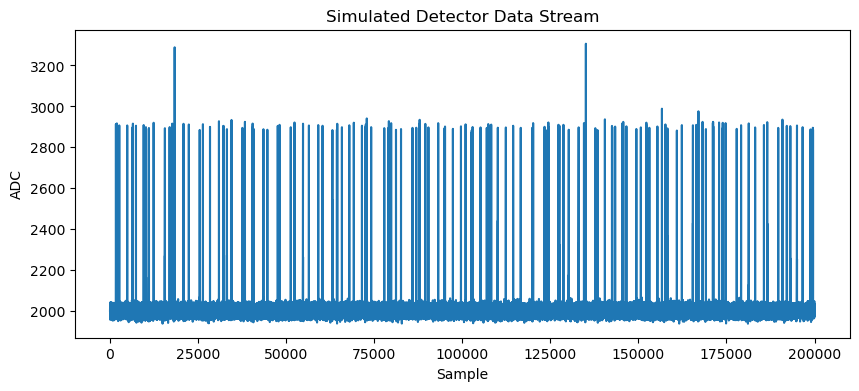

In [440]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(waveform)
plt.title("Simulated Detector Data Stream")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

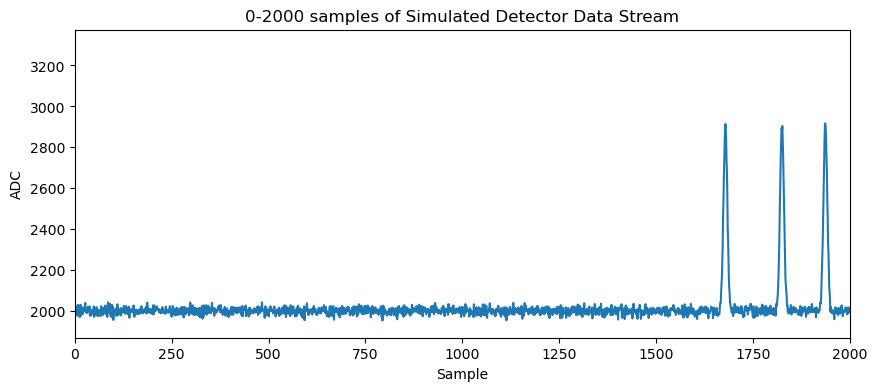

In [441]:
plt.figure(figsize=(10,4))
plt.plot(waveform)
plt.title("0-2000 samples of Simulated Detector Data Stream")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.xlim(0, 2000)
plt.show()

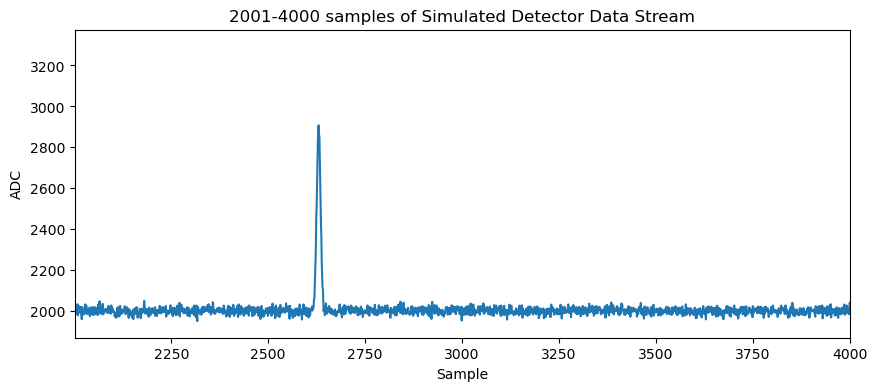

In [442]:
plt.figure(figsize=(10,4))
plt.plot(waveform)
plt.title("2001-4000 samples of Simulated Detector Data Stream")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.xlim(2001, 4000)
plt.show()

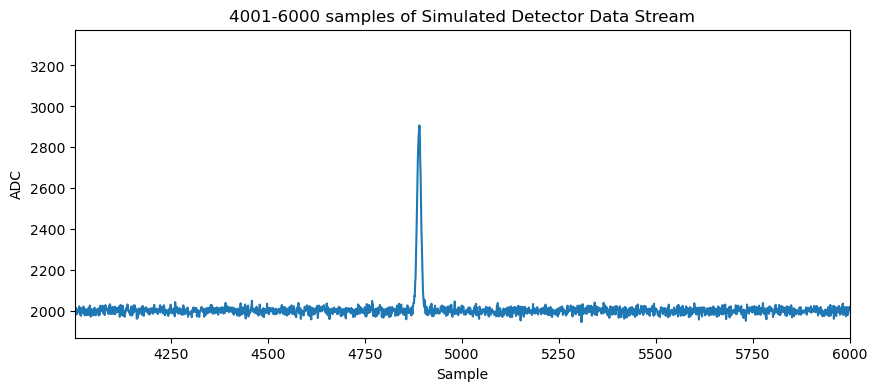

In [443]:
plt.figure(figsize=(10,4))
plt.plot(waveform)
plt.title("4001-6000 samples of Simulated Detector Data Stream")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.xlim(4001, 6000)
plt.show()

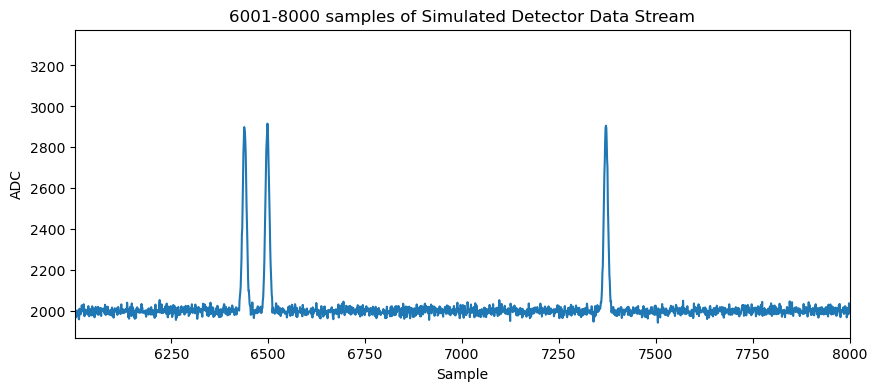

In [444]:
plt.figure(figsize=(10,4))
plt.plot(waveform)
plt.title("6001-8000 samples of Simulated Detector Data Stream")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.xlim(6001, 8000)
plt.show()

In [445]:
#whole time window 2 us
#assume 1Gsample/second
#range 0-2000 samples = 0-2 us
#lower probability for 2 peaks - 1 peak still 100%
#make sparser
#just look at 2 us
#change the spacing between pulses random
#98% prob of exactly one pulse within the whole 2000 sample window
#10% change of the double pulse within the 2000 sample window
